# Blinkit Sales Analysis

### Importing Libraries:

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

### Importing raw data:

In [4]:
df= pd.read_csv("C:/Users/Prachi Priya/Downloads/blinkit_data (1).csv")

In [5]:
df.head(3)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0


### Size of Data:

In [10]:
print("Size of Data:", df.shape)

Size of Data: (8523, 12)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [12]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

### Data Cleaning:

In [13]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [16]:
df["Item Fat Content"]=  df["Item Fat Content"].replace({"low fat":"Low Fat" , "LF": "Low Fat", "reg": "Low Fat"})

In [17]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat']


In [19]:
df = df.drop(columns = ["Item Visibility", "Item Weight" ])

In [20]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Sales',
       'Rating'],
      dtype='object')

# KPIs--

### (a) Total Revenue:

In [30]:
print("Total Revenue:", "$", round(df["Sales"].sum(),2))

Total Revenue: $ 1201681.48


### (b) Average Sales:

In [31]:
print("Average Revenue:", "$", round(df["Sales"].mean(), 2))

Average Revenue: $ 140.99


### (c) Number of items:

In [32]:
print("Number of Items:", df["Item Identifier"].count())

Number of Items: 8523


### (d) Average Rating:

In [33]:
print("Average Rating:", round(df["Rating"].mean(),2))

Average Rating: 3.97


# Charts--

### (a) Total Sales by Fat Content:

In [42]:
Sales_Fat = df.groupby("Item Fat Content")["Sales"].sum()

fig=px.pie(Sales_Fat, names= Sales_Fat.index, values = Sales_Fat.values, hole=0.4,
          title="Total Sales by Fat Content")

fig.update_traces(textinfo="percent+label", pull=[0.05,0])

### (b) Total Sales by Item Type:

In [43]:
df["Item Type"].value_counts()

Item Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [45]:
sales_Item_type = df.groupby("Item Type")["Sales"].sum()

px.bar(sales_Item_type, sales_Item_type.index, sales_Item_type.values, title = " Total Sales by Item Type",
      labels= {"x": "Item Type", "y": "Total Revenue"})

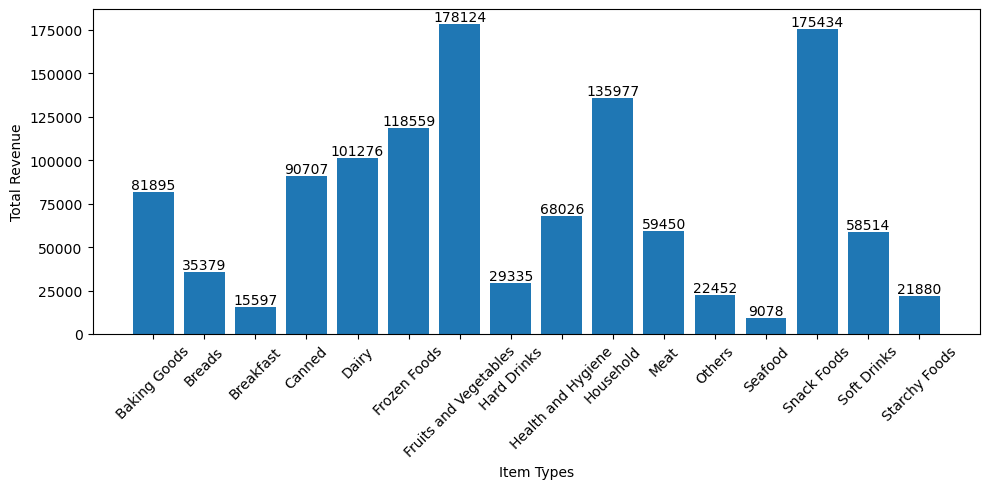

In [57]:
plt.figure(figsize=(10,5))

bars = plt.bar( sales_Item_type.index, sales_Item_type.values)

plt.bar_label(bars, fmt="{:.0f}")

plt.xticks(rotation = 45)
plt.xlabel("Item Types")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

### (c) Fat Content by Outlet Location for Revenue:

In [60]:
data = df.groupby(["Outlet Location Type", "Item Fat Content"])["Sales"].sum()
data

Outlet Location Type  Item Fat Content
Tier 1                Low Fat             220117.4480
                      Regular             116280.3640
Tier 2                Low Fat             259242.3174
                      Regular             133908.3242
Tier 3                Low Fat             312908.5940
                      Regular             159224.4332
Name: Sales, dtype: float64

In [62]:
data = df.groupby(["Outlet Location Type", "Item Fat Content"])["Sales"].sum().unstack()
data

# unstack() converts the inner index (Item Fat Content) into separate columns!! Your data becomes a table like:

Item Fat Content,Low Fat,Regular
Outlet Location Type,,
Tier 1,220117.4480,116280.3640
Tier 2,259242.3174,133908.3242
Tier 3,312908.5940,159224.4332


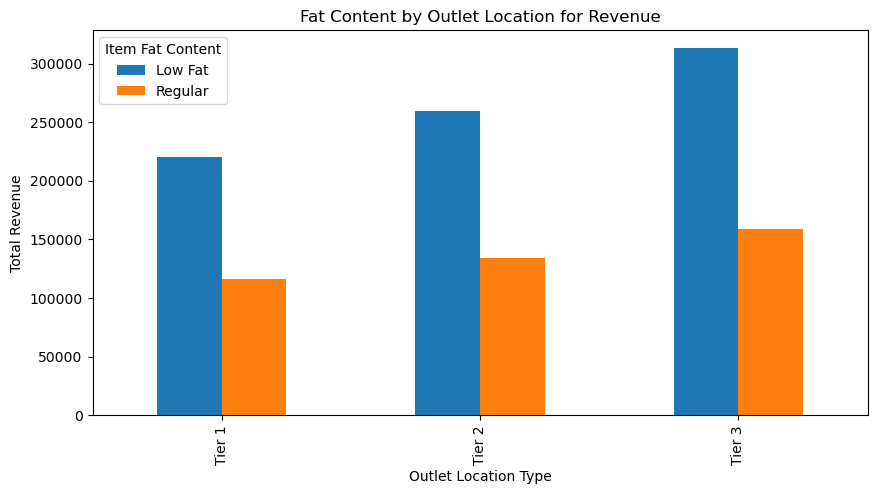

In [66]:
data.plot(kind="bar", figsize=(10,5))
plt.ylabel("Total Revenue")
plt.title("Fat Content by Outlet Location for Revenue")

plt.show()

### (d) Total Sales by outlet Establishment:

In [67]:
df["Outlet Establishment Year"].value_counts()

Outlet Establishment Year
1998    1463
2000     932
2012     930
2010     930
2017     930
2015     929
2022     928
2020     926
2011     555
Name: count, dtype: int64

In [71]:
outlet = df.groupby("Outlet Establishment Year")["Sales"].sum()

px.line(outlet, x=outlet.index, y=outlet.values, title = "Total Revenue by outlet Establishment",
       labels = {"x":"Outlet Establishment Year", "y": "Total Revenue"})

### (e) Total Sales by Outlet Size:

In [73]:
df["Outlet Size"].value_counts()

Outlet Size
Medium    3631
Small     3139
High      1753
Name: count, dtype: int64

In [79]:
Outlet_Size = df.groupby("Outlet Size")["Sales"].sum()

fig = px.pie(Outlet_Size, names = Outlet_Size.index, values = Outlet_Size.values, hole=0.4,
             title="Total Revenue by Outlet Size")

fig.update_traces(textinfo="percent+label", pull=[0.005, 0])

### (f) Total Sales by outlet Location:

In [80]:
df["Outlet Location Type"].value_counts()

Outlet Location Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

In [83]:
Outlet_location = df.groupby("Outlet Location Type")["Sales"].sum()

fig = px.pie(Outlet_location, names=Outlet_location.index, values=Outlet_location.values, hole=0.4,
      title="Total Revenue by outlet Location")

fig.update_traces(textinfo="percent+label", pull = [0.005, 0])